# Session 8 - pandas

pandas is the go-to library for data manipulation and analysis in Python. If NumPy is the engine, pandas is the dashboard, steering wheel, and GPS all in one.

Built on top of NumPy, pandas adds two powerful data structures:

- **Series** — a 1-D labeled array (like a single column in a spreadsheet)
- **DataFrame** — a 2-D labeled table (like a whole spreadsheet)

The labels (called *indexes*) are what make pandas so powerful. Instead of remembering that column 3 is "age," you just use `df["age"]`.

We'll work through the essential pandas operations using the Pokemon dataset as our running example.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading Data

The first step in any data project is loading data. pandas can read from CSV, Excel, JSON, SQL databases, HTML tables, and more. The most common is `read_csv()`:

In [2]:
df = pd.read_csv("pokemon/pokemon.csv")
print(f"Shape: {df.shape}")  # (rows, columns)
print(f"Columns: {list(df.columns[:5])} ...")  # Show first 5 column names

Shape: (801, 41)
Columns: ['abilities', 'against_bug', 'against_dark', 'against_dragon', 'against_electric'] ...


### First Things First: `info()` and `describe()`

Before doing anything, always run these two methods. They tell you what you're working with:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   abilities          801 non-null    object 
 1   against_bug        801 non-null    float64
 2   against_dark       801 non-null    float64
 3   against_dragon     801 non-null    float64
 4   against_electric   801 non-null    float64
 5   against_fairy      801 non-null    float64
 6   against_fight      801 non-null    float64
 7   against_fire       801 non-null    float64
 8   against_flying     801 non-null    float64
 9   against_ghost      801 non-null    float64
 10  against_grass      801 non-null    float64
 11  against_ground     801 non-null    float64
 12  against_ice        801 non-null    float64
 13  against_normal     801 non-null    float64
 14  against_poison     801 non-null    float64
 15  against_psychic    801 non-null    float64
 16  against_rock       801 non

From `info()` we can see:
- 801 rows, 41 columns
- Some columns have missing values (e.g., `type2` has only 417 non-null values)
- Most columns are `float64` or `int64`, but a few are `object` (strings)
- Memory usage: ~257 KB

Now let's get statistical summaries of the numeric columns:

In [4]:
df.describe()

,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,...,height_m,hp,percentage_male,pokedex_number,sp_attack,sp_defense,speed,weight_kg,generation,is_legendary
count,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,...,781.000000,801.000000,703.000000,801.000000,801.000000,801.000000,801.000000,781.000000,801.000000,801.000000
mean,0.996255,1.057116,0.968789,1.073970,1.068976,1.065543,1.135456,1.192884,0.985019,1.034020,...,1.163892,68.958801,55.155761,401.000000,71.305868,70.911361,66.334582,61.378105,3.690387,0.087391
std,0.597248,0.438142,0.353058,0.654962,0.522167,0.717251,0.691853,0.604488,0.558256,0.788896,...,1.080326,26.576015,20.261623,231.373075,32.353826,27.942501,28.907662,109.354766,1.930420,0.282583
min,0.250000,0.250000,0.000000,0.000000,0.250000,0.000000,0.250000,0.250000,0.000000,0.250000,...,0.100000,1.000000,0.000000,1.000000,10.000000,20.000000,5.000000,0.100000,1.000000,0.000000
25%,0.500000,1.000000,1.000000,0.500000,1.000000,0.500000,0.500000,1.000000,1.000000,0.500000,...,0.600000,50.000000,50.000000,201.000000,45.000000,50.000000,45.000000,9.000000,2.000000,0.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,65.000000,50.000000,401.000000,65.000000,66.000000,65.000000,27.300000,4.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,1.500000,80.000000,50.000000,601.000000,91.000000,90.000000,85.000000,64.800000,5.000000,0.000000
max,4.000000,4.000000,2.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,14.500000,255.000000,100.000000,801.000000,194.000000,230.000000,180.000000,999.900000,7.000000,1.000000


And a quick peek at the first few rows:

In [5]:
df.head()

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


In [6]:
# Test: Verify data loading
assert df.shape == (801, 41), f"Expected (801, 41), got {df.shape}"
assert "name" in df.columns
assert "type1" in df.columns
assert df["hp"].dtype == np.int64
assert df["attack"].dtype == np.int64
assert len(df) == 801
print("Data loading tests passed!")

Data loading tests passed!


## Series vs DataFrame

Understanding the difference is important:

- A **DataFrame** is a table (2D)
- A **Series** is a single column (1D)

When you select a single column from a DataFrame, you get a Series:

In [7]:
# Selecting a column returns a Series
names = df["name"]
print(f"Type: {type(names)}")
print(f"Shape: {names.shape}")
print(f"First 5:\n{names.head()}")

Type: <class 'pandas.core.series.Series'>
Shape: (801,)
First 5:
0     Bulbasaur
1       Ivysaur
2      Venusaur
3    Charmander
4    Charmeleon
Name: name, dtype: object


In [8]:
# Selecting multiple columns returns a DataFrame
subset = df[["name", "type1", "hp"]]
print(f"Type: {type(subset)}")
print(f"Shape: {subset.shape}")
subset.head()

Type: <class 'pandas.core.frame.DataFrame'>
Shape: (801, 3)


,name,type1,hp
0,Bulbasaur,grass,45
1,Ivysaur,grass,60
2,Venusaur,grass,80
3,Charmander,fire,39
4,Charmeleon,fire,58


## Selecting Rows: `.loc` and `.iloc`

There are two ways to select rows:

- `.iloc[]` — select by **integer position** (row number)
- `.loc[]` — select by **label** (index value)

Right now our index is just row numbers (0, 1, 2, ...), so they work the same:

In [9]:
# Get row 10 by position
row = df.iloc[10]
print(f"Pokemon at row 10: {row['name']}")
print(f"Type: {row['type1']}")
print(f"HP: {row['hp']}")

Pokemon at row 10: Metapod
Type: bug
HP: 50


But what if we set the Pokédex number as the index? Then `.loc` becomes much more intuitive:

In [10]:
# Set pokedex_number as the index
df = df.set_index("pokedex_number")
print(f"Index name: {df.index.name}")
print(f"First 5 index values: {list(df.index[:5])}")

Index name: pokedex_number
First 5 index values: [1, 2, 3, 4, 5]


In [11]:
# Now .loc uses the pokedex number directly
pikachu = df.loc[25]
print(f"Pokemon #25: {pikachu['name']}")
print(f"Type: {pikachu['type1']}")
print(f"Attack: {pikachu['attack']}")

Pokemon #25: Pikachu
Type: electric
Attack: 55


In [12]:
# Select multiple rows by label
df.loc[[1, 4, 7], ["name", "type1", "attack"]]

,name,type1,attack
pokedex_number,,,
1,Bulbasaur,grass,49
4,Charmander,fire,52
7,Squirtle,water,48


In [13]:
# Test: Verify .loc and .iloc
# Reset for testing
test_df = pd.DataFrame({
    "name": ["A", "B", "C"],
    "value": [10, 20, 30]
})

assert test_df.iloc[0]["name"] == "A"
assert test_df.iloc[1]["value"] == 20

# With custom index
test_df = test_df.set_index("name")
assert test_df.loc["B"]["value"] == 20
assert test_df.loc["C"]["value"] == 30
print("loc/illoc tests passed!")

loc/illoc tests passed!


## Filtering with Boolean Indexing

This is how you subset data — the pandas equivalent of SQL's `WHERE` clause. Create a boolean condition and use it to filter rows:

In [14]:
# All Pokemon lighter than 25 kg
light = df[df["weight_kg"] < 25]
print(f"Pokemon under 25kg: {len(light)} out of {len(df)}")
light[["name", "type1", "weight_kg"]].head(10)

Pokemon under 25kg: 372 out of 801


,name,type1,weight_kg
pokedex_number,,,
1,Bulbasaur,grass,6.9
2,Ivysaur,grass,13.0
4,Charmander,fire,8.5
5,Charmeleon,fire,19.0
7,Squirtle,water,9.0
8,Wartortle,water,22.5
10,Caterpie,bug,2.9
11,Metapod,bug,9.9
13,Weedle,bug,3.2


In [15]:
# Combine conditions with & (AND) and | (OR)
# Note: Each condition needs parentheses!
fire_and_heavy = df[(df["type1"] == "fire") & (df["weight_kg"] > 50)]
print(f"Fire types over 50kg: {len(fire_and_heavy)}")
fire_and_heavy[["name", "weight_kg", "attack"]]

Fire types over 50kg: 22


,name,weight_kg,attack
pokedex_number,,,
6,Charizard,90.5,104
59,Arcanine,155.0,110
78,Rapidash,95.0,100
146,Moltres,60.0,100
157,Typhlosion,79.5,84
219,Magcargo,55.0,50
244,Entei,198.0,115
250,Ho-Oh,199.0,130
257,Blaziken,52.0,160


### Using `.query()` for Readability

For complex filters, `.query()` is often cleaner:

In [16]:
# Same filter, different syntax
light_query = df.query("weight_kg < 25")
assert len(light) == len(light_query), "query() should match boolean indexing"

# Complex query: legendary pokemon with speed over 100
fast_legendaries = df.query("is_legendary == 1 and speed > 100")
print(f"Fast legendaries (speed > 100): {len(fast_legendaries)}")
fast_legendaries[["name", "speed", "type1"]]

Fast legendaries (speed > 100): 23


,name,speed,type1
pokedex_number,,,
150,Mewtwo,140,psychic
243,Raikou,115,electric
249,Lugia,110,psychic
380,Latias,110,dragon
381,Latios,110,dragon
384,Rayquaza,115,dragon
386,Deoxys,180,psychic
482,Azelf,115,psychic
491,Darkrai,125,dark


In [17]:
# Test: Verify filtering
assert len(df[df["hp"] > 100]) > 0
assert len(df.query("hp > 100")) == len(df[df["hp"] > 100])

# Combined conditions
result = df[(df["attack"] > 100) & (df["defense"] > 100)]
assert all(result["attack"] > 100)
assert all(result["defense"] > 100)
print("Filtering tests passed!")

Filtering tests passed!


## Creating New Columns

Just like a dictionary, you can add new columns by assigning to them. Because of NumPy broadcasting underneath, vectorized operations are fast:

In [18]:
# Z-score of base_total
df["base_total_zscore"] = (df["base_total"] - df["base_total"].mean()) / df["base_total"].std()

# Attack/Defense ratio
df["atk_def_ratio"] = df["attack"] / df["defense"]

# Size category
df["size_category"] = pd.cut(
    df["weight_kg"],
    bins=[0, 10, 50, 100, float("inf")],
    labels=["Tiny", "Small", "Medium", "Heavy"]
)

df[["name", "base_total", "base_total_zscore", "atk_def_ratio", "size_category"]].head(10)

,name,base_total,base_total_zscore,atk_def_ratio,size_category
pokedex_number,,,,,
1,Bulbasaur,318,-0.925954,1.000000,Tiny
2,Ivysaur,405,-0.196110,0.984127,Small
3,Venusaur,625,1.649472,0.813008,Medium
4,Charmander,309,-1.001455,1.209302,Tiny
5,Charmeleon,405,-0.196110,1.103448,Small
6,Charizard,634,1.724973,1.333333,Medium
7,Squirtle,314,-0.959510,0.738462,Tiny
8,Wartortle,405,-0.196110,0.787500,Small
9,Blastoise,630,1.691417,0.858333,Medium


In [19]:
# Test: Verify column creation
assert "base_total_zscore" in df.columns
assert "atk_def_ratio" in df.columns
assert "size_category" in df.columns

# Z-score should have mean ~0
assert abs(df["base_total_zscore"].mean()) < 0.01

# Ratio should be positive
assert all(df["atk_def_ratio"] > 0)
print("Column creation tests passed!")

Column creation tests passed!


## Using `.apply()` and `.map()`

When vectorized operations aren't enough, `.apply()` lets you run custom functions on rows or columns. `.map()` is for transforming values in a Series:

In [20]:
# Map: capitalize type names consistently
df["type1_clean"] = df["type1"].str.title()

# Apply: custom function on each row
def get_power_rating(row):
    """Calculate a simple power rating from base stats.
    
    Args:
        row: A DataFrame row with stat columns.
        
    Returns:
        A string rating.
    """
    total = row["base_total"]
    if total >= 600:
        return "Legendary"
    elif total >= 500:
        return "Strong"
    elif total >= 400:
        return "Average"
    else:
        return "Weak"


df["power_rating"] = df.apply(get_power_rating, axis=1)

# Show the distribution
print(df["power_rating"].value_counts())

power_rating
Weak         315
Average      258
Strong       158
Legendary     70
Name: count, dtype: int64


In [21]:
# Test: Verify apply and map
test_data = pd.DataFrame({"name": ["A", "B", "C"], "base_total": [300, 450, 650]})
test_data["power_rating"] = test_data.apply(get_power_rating, axis=1)
assert test_data.loc[0, "power_rating"] == "Weak"
assert test_data.loc[1, "power_rating"] == "Average"
assert test_data.loc[2, "power_rating"] == "Legendary"
print("Apply and map tests passed!")

Apply and map tests passed!


## Handling Missing Data

Real data is messy. pandas makes it easy to find and deal with missing values:

In [22]:
# Count missing values per column
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

type2              384
percentage_male     98
height_m            20
weight_kg           20
size_category       20
dtype: int64

The `type2` column has lots of missing values — that makes sense, since not all Pokemon have a second type. For `height_m` and `weight_kg`, the missing values are data gaps.

Common strategies:
- **Drop** rows with missing values: `df.dropna()`
- **Fill** with a value: `df.fillna(0)`
- **Fill** with a statistic: `df.fillna(df.median())`

In [23]:
# Fill missing height/weight with the median
df["height_m"] = df["height_m"].fillna(df["height_m"].median())
df["weight_kg"] = df["weight_kg"].fillna(df["weight_kg"].median())

# Verify no more missing values in these columns
print(f"Missing height: {df['height_m'].isnull().sum()}")
print(f"Missing weight: {df['weight_kg'].isnull().sum()}")

Missing height: 0
Missing weight: 0


In [24]:
# Test: Verify missing data handling
test_series = pd.Series([1, 2, np.nan, 4, np.nan])
filled = test_series.fillna(test_series.median())
assert filled.isnull().sum() == 0
assert filled[2] == 2.0  # Median of [1, 2, 4] is 2

# dropna
dropped = test_series.dropna()
assert len(dropped) == 3
print("Missing data tests passed!")

Missing data tests passed!


## GroupBy and Aggregation

This is where pandas really shines. The split-apply-combine pattern lets you answer questions like "What's the average HP for each type?" in one line:

1. **Split** the data into groups
2. **Apply** an aggregation function to each group
3. **Combine** the results into a new DataFrame

In [25]:
# Average stats by type
type_stats = df.groupby("type1")[["hp", "attack", "defense", "speed"]].mean().round(1)
type_stats

,hp,attack,defense,speed
type1,,,,
bug,56.7,70.1,70.8,63.6
dark,72.6,87.8,70.5,75.3
dragon,79.9,106.4,86.3,76.1
electric,60.5,70.8,61.8,85.4
fairy,73.9,62.1,68.2,53.7
fighting,71.4,99.2,66.4,64.3
fire,68.7,81.5,67.8,73.3
flying,68.0,66.7,65.0,99.7
ghost,63.4,72.7,79.5,58.3


In [26]:
# Multiple aggregations at once
type_summary = df.groupby("type1").agg(
    count=("name", "count"),
    avg_attack=("attack", "mean"),
    max_attack=("attack", "max"),
    avg_speed=("speed", "mean"),
).round(1)

# Sort by average attack
type_summary.sort_values("avg_attack", ascending=False)

,count,avg_attack,max_attack,avg_speed
type1,,,,
dragon,27,106.4,180,76.1
fighting,28,99.2,145,64.3
ground,32,94.8,180,60.0
steel,24,93.1,150,56.6
rock,45,90.7,165,57.4
dark,29,87.8,150,75.3
fire,52,81.5,160,73.3
normal,105,75.2,160,69.5
grass,78,73.8,181,59.0


In [27]:
# Which type has the highest total stats on average?
df.groupby("type1")["base_total"].mean().sort_values(ascending=False).head(10)

type1
dragon      522.777778
steel       491.583333
psychic     461.264151
flying      453.333333
fire        450.634615
dark        449.758621
rock        447.266667
electric    436.153846
ghost       434.703704
ice         433.608696
Name: base_total, dtype: float64

In [28]:
# Test: Verify groupby operations
test_df = pd.DataFrame({
    "group": ["A", "A", "B", "B"],
    "value": [10, 20, 30, 40]
})

# Mean by group
means = test_df.groupby("group")["value"].mean()
assert means["A"] == 15.0
assert means["B"] == 35.0

# Multiple aggregations
agg = test_df.groupby("group").agg(
    count=("value", "count"),
    total=("value", "sum")
)
assert agg.loc["A", "count"] == 2
assert agg.loc["A", "total"] == 30
print("GroupBy tests passed!")

GroupBy tests passed!


## Sorting and Ranking

Quickly find the top entries:

In [29]:
# Top 10 by attack
top_attack = df.nlargest(10, "attack")[["name", "type1", "attack", "base_total"]]
print("Top 10 by attack:")
top_attack

Top 10 by attack:


,name,type1,attack,base_total
pokedex_number,,,,
214,Heracross,bug,185,600
798,Kartana,grass,181,570
383,Groudon,ground,180,770
384,Rayquaza,dragon,180,780
445,Garchomp,dragon,170,700
354,Banette,ghost,165,555
409,Rampardos,rock,165,495
475,Gallade,psychic,165,618
248,Tyranitar,rock,164,700


In [30]:
# Rank all Pokemon by base_total
df["rank"] = df["base_total"].rank(ascending=False, method="min").astype(int)

# Show the top 5
df.nsmallest(5, "rank")[["name", "base_total", "rank"]]

,name,base_total,rank
pokedex_number,,,
150,Mewtwo,780,1
384,Rayquaza,780,1
382,Kyogre,770,3
383,Groudon,770,3
493,Arceus,720,5


In [31]:
# Test: Verify sorting and ranking
test_df = pd.DataFrame({"name": ["A", "B", "C"], "score": [30, 10, 20]})

top = test_df.nlargest(1, "score")
assert top.iloc[0]["name"] == "A"

bottom = test_df.nsmallest(1, "score")
assert bottom.iloc[0]["name"] == "B"

# Rank
test_df["rank"] = test_df["score"].rank(ascending=False).astype(int)
assert test_df.loc[0, "rank"] == 1  # A has highest score
print("Sorting and ranking tests passed!")

Sorting and ranking tests passed!


## Value Counts and Crosstabs

Quick frequency analysis:

In [32]:
# Distribution of primary types
type_counts = df["type1"].value_counts()
print("Type distribution:")
print(type_counts)

Type distribution:
type1
water       114
normal      105
grass        78
bug          72
psychic      53
fire         52
rock         45
electric     39
poison       32
ground       32
dark         29
fighting     28
dragon       27
ghost        27
steel        24
ice          23
fairy        18
flying        3
Name: count, dtype: int64


In [33]:
# Crosstab: type vs legendary status
pd.crosstab(df["type1"], df["is_legendary"], rownames=["Type"], colnames=["Legendary"])

Legendary,0,1
Type,,
bug,69,3
dark,26,3
dragon,20,7
electric,34,5
fairy,17,1
fighting,28,0
fire,47,5
flying,2,1
ghost,26,1


In [34]:
# Test: Verify value_counts and crosstab
test_series = pd.Series(["a", "a", "b", "c", "a"])
counts = test_series.value_counts()
assert counts["a"] == 3
assert counts["b"] == 1

# Crosstab
ct = pd.crosstab(pd.Series(["X", "X", "Y"]), pd.Series([1, 0, 1]))
assert ct.loc["X", 0] == 1
assert ct.loc["Y", 1] == 1
print("Value counts and crosstab tests passed!")

Value counts and crosstab tests passed!


## Combining DataFrames

In real projects you'll often need to merge data from multiple sources. pandas provides `concat()` to stack DataFrames and `merge()` to join them:

In [35]:
# Create two small DataFrames
df1 = pd.DataFrame({"id": [1, 2, 3], "name": ["A", "B", "C"], "score": [90, 80, 70]})
df2 = pd.DataFrame({"id": [4, 5], "name": ["D", "E"], "score": [60, 50]})

# Stack them vertically (pd.concat replaces the deprecated .append)
combined = pd.concat([df1, df2], ignore_index=True)
print("Combined (concat):")
print(combined)

Combined (concat):
   id name  score
0   1    A     90
1   2    B     80
2   3    C     70
3   4    D     60
4   5    E     50


In [36]:
# Join on a key column
grades = pd.DataFrame({"id": [1, 2, 3], "grade": ["A", "B", "C"]})
merged = df1.merge(grades, on="id", how="left")
print("Merged (merge on id):")
print(merged)

Merged (merge on id):
   id name  score grade
0   1    A     90     A
1   2    B     80     B
2   3    C     70     C


In [37]:
# Test: Verify concat and merge
a = pd.DataFrame({"x": [1, 2]})
b = pd.DataFrame({"x": [3, 4]})
result = pd.concat([a, b], ignore_index=True)
assert len(result) == 4
assert list(result["x"]) == [1, 2, 3, 4]

# Merge
left = pd.DataFrame({"id": [1, 2], "val": ["a", "b"]})
right = pd.DataFrame({"id": [1, 2], "score": [100, 200]})
merged = left.merge(right, on="id")
assert len(merged) == 2
assert merged.loc[0, "val"] == "a"
assert merged.loc[0, "score"] == 100
print("Concat and merge tests passed!")

Concat and merge tests passed!


## String Methods

pandas gives you vectorized string operations through the `.str` accessor:

In [38]:
# Clean up the abilities column: count how many abilities each Pokemon has
df["num_abilities"] = df["abilities"].str.count(",") + 1

# Find Pokemon whose names contain a specific pattern
df["name_length"] = df["name"].str.len()

# Extract the first ability
df["first_ability"] = df["abilities"].str.extract(r"'([^']+)'", expand=False)

df[["name", "abilities", "num_abilities", "first_ability", "name_length"]].head(10)

,name,abilities,num_abilities,first_ability,name_length
pokedex_number,,,,,
1,Bulbasaur,"['Overgrow', 'Chlorophyll']",2,Overgrow,9
2,Ivysaur,"['Overgrow', 'Chlorophyll']",2,Overgrow,7
3,Venusaur,"['Overgrow', 'Chlorophyll']",2,Overgrow,8
4,Charmander,"['Blaze', 'Solar Power']",2,Blaze,10
5,Charmeleon,"['Blaze', 'Solar Power']",2,Blaze,10
6,Charizard,"['Blaze', 'Solar Power']",2,Blaze,9
7,Squirtle,"['Torrent', 'Rain Dish']",2,Torrent,8
8,Wartortle,"['Torrent', 'Rain Dish']",2,Torrent,9
9,Blastoise,"['Torrent', 'Rain Dish']",2,Torrent,9


In [39]:
# Test: Verify string methods
test_series = pd.Series(["hello", "WORLD", "Python"])
assert test_series.str.upper().iloc[0] == "HELLO"
assert test_series.str.lower().iloc[1] == "world"
assert test_series.str.contains("thon").iloc[2]
assert test_series.str.len().iloc[0] == 5
print("String method tests passed!")

String method tests passed!


## Visualization

pandas has built-in plotting powered by matplotlib. Just call `.plot()` on a Series or DataFrame:

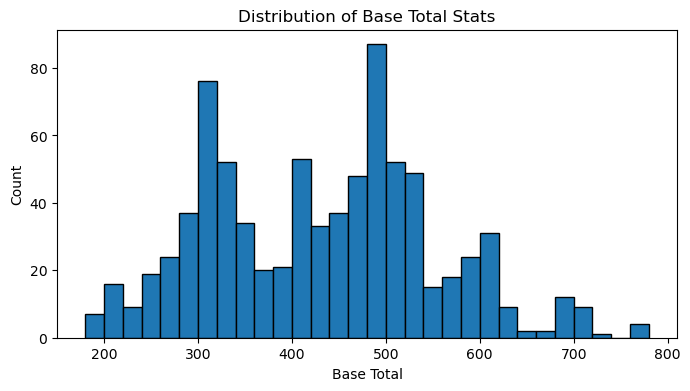

In [40]:
# Histogram of base_total
df["base_total"].plot(kind="hist", bins=30, edgecolor="black", figsize=(8, 4))
plt.title("Distribution of Base Total Stats")
plt.xlabel("Base Total")
plt.ylabel("Count")
plt.show()

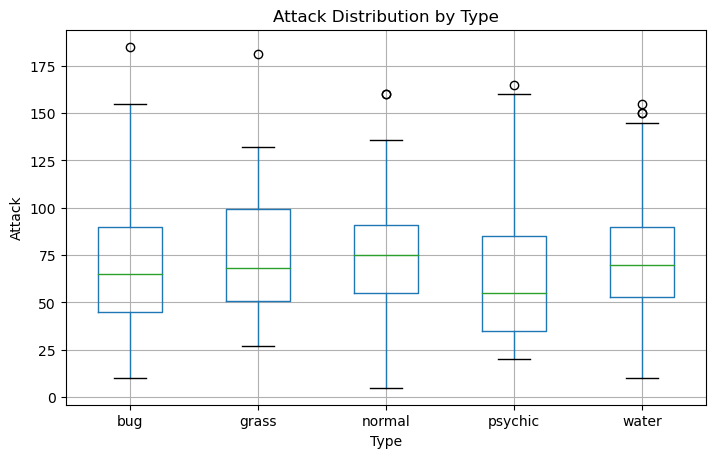

In [41]:
# Box plot: attack by type (top 5 types)
top_types = df["type1"].value_counts().head(5).index
subset = df[df["type1"].isin(top_types)]

subset.boxplot(column="attack", by="type1", figsize=(8, 5))
plt.title("Attack Distribution by Type")
plt.suptitle("")
plt.xlabel("Type")
plt.ylabel("Attack")
plt.show()

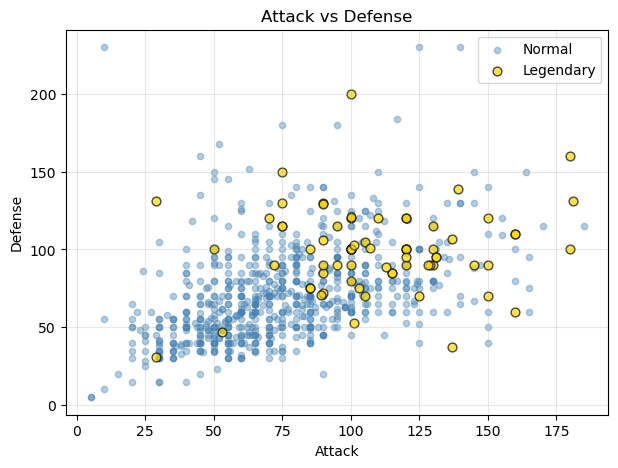

In [42]:
# Scatter plot: attack vs defense, colored by legendary status
fig, ax = plt.subplots(figsize=(7, 5))

normal = df[df["is_legendary"] == 0]
legendary = df[df["is_legendary"] == 1]

ax.scatter(normal["attack"], normal["defense"], alpha=0.4, s=20, label="Normal", color="steelblue")
ax.scatter(legendary["attack"], legendary["defense"], alpha=0.7, s=40, label="Legendary", color="gold", edgecolors="black")

ax.set_xlabel("Attack")
ax.set_ylabel("Defense")
ax.set_title("Attack vs Defense")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

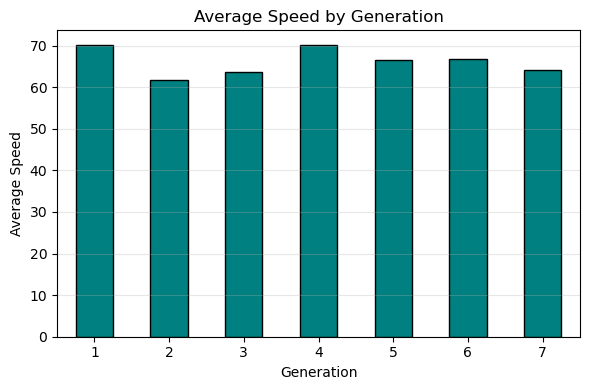

In [43]:
# Bar chart: average speed by generation
speed_by_gen = df.groupby("generation")["speed"].mean()
speed_by_gen.plot(kind="bar", figsize=(6, 4), color="teal", edgecolor="black")
plt.title("Average Speed by Generation")
plt.xlabel("Generation")
plt.ylabel("Average Speed")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Putting It All Together: A Mini Analysis

Let's answer a real question: **"Which Pokemon types have the best overall stats, and how do legendaries compare?"**

In [44]:
# 1. Compute average base_total by type
type_avg = df.groupby("type1")["base_total"].mean().sort_values(ascending=False)

# 2. Compare legendary vs non-legendary averages
legendary_avg = df.groupby("is_legendary")["base_total"].mean()

print("Average Base Total by Type:")
print(type_avg.round(1))
print()
print(f"Non-legendary average: {legendary_avg[0]:.1f}")
print(f"Legendary average: {legendary_avg[1]:.1f}")
print(f"Legendaries are {legendary_avg[1]/legendary_avg[0]:.1f}x stronger on average")

Average Base Total by Type:
type1
dragon      522.8
steel       491.6
psychic     461.3
flying      453.3
fire        450.6
dark        449.8
rock        447.3
electric    436.2
ghost       434.7
ice         433.6
fairy       427.2
water       426.8
ground      426.1
fighting    414.8
grass       412.6
normal      401.3
poison      399.6
bug         380.4
Name: base_total, dtype: float64

Non-legendary average: 410.5
Legendary average: 615.3
Legendaries are 1.5x stronger on average


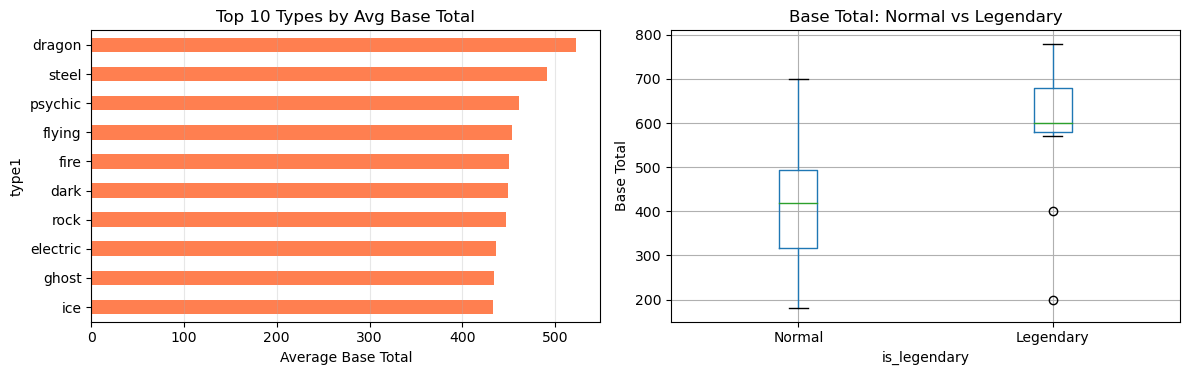

In [45]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Bar chart of type averages
type_avg.head(10).plot(kind="barh", ax=axes[0], color="coral")
axes[0].set_title("Top 10 Types by Avg Base Total")
axes[0].set_xlabel("Average Base Total")
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.3)

# Right: Violin-like comparison (using box plot)
df.boxplot(column="base_total", by="is_legendary", ax=axes[1])
axes[1].set_title("Base Total: Normal vs Legendary")
axes[1].set_xticklabels(["Normal", "Legendary"])
axes[1].set_ylabel("Base Total")
plt.suptitle("")

plt.tight_layout()
plt.show()

## Working with NumPy Arrays

Remember that pandas is built on NumPy. You can always access the underlying array with `.values`:

In [46]:
# Extract a column as a NumPy array
attack_array = df["attack"].values
print(f"Type: {type(attack_array)}")
print(f"Shape: {attack_array.shape}")
print(f"Mean (NumPy): {attack_array.mean():.1f}")
print(f"Mean (pandas): {df['attack'].mean():.1f}")

Type: <class 'numpy.ndarray'>
Shape: (801,)
Mean (NumPy): 77.9
Mean (pandas): 77.9


In [47]:
# Convert entire DataFrame to NumPy array
stats = df[["hp", "attack", "defense", "sp_attack", "sp_defense", "speed"]].values
print(f"Stats array shape: {stats.shape}")
print(f"Mean of each stat: {stats.mean(axis=0).round(1)}")

Stats array shape: (801, 6)
Mean of each stat: [69.  77.9 73.  71.3 70.9 66.3]


## Summary

You've covered the essential pandas concepts:

- **Loading data** — `pd.read_csv()`, `df.info()`, `df.describe()`
- **Selecting data** — column selection, `.loc`, `.iloc`
- **Filtering** — boolean indexing, `.query()`
- **Creating columns** — vectorized operations, `.apply()`, `.map()`
- **Missing data** — `isnull()`, `fillna()`, `dropna()`
- **GroupBy** — `groupby()`, `agg()`, `value_counts()`
- **Sorting** — `nlargest()`, `nsmallest()`, `rank()`
- **Combining** — `pd.concat()`, `merge()`
- **String methods** — `.str.count()`, `.str.extract()`, `.str.len()`
- **Visualization** — `.plot()`, `.boxplot()`, matplotlib integration

### Quick Reference

| Task | pandas approach |
|------|----------------|
| Load CSV | `pd.read_csv("file.csv")` |
| First rows | `df.head()` |
| Summary stats | `df.describe()` |
| Select column | `df["column"]` |
| Select rows by position | `df.iloc[0:5]` |
| Select rows by label | `df.loc[label]` |
| Filter rows | `df[df["col"] > value]` |
| Create column | `df["new"] = df["a"] + df["b"]` |
| Group and aggregate | `df.groupby("col")["val"].mean()` |
| Multiple aggregations | `df.groupby("col").agg(...)` |
| Fill missing values | `df.fillna(value)` |
| Sort | `df.sort_values("col", ascending=False)` |
| Count values | `df["col"].value_counts()` |
| Concatenate | `pd.concat([df1, df2])` |
| Merge | `df1.merge(df2, on="key")` |
| Plot | `df["col"].plot(kind="hist")` |

You now have the foundation to explore real datasets. In the project notebooks, you'll put all of this together for Exploratory Data Analysis and machine learning.